## Day 3 — Bias-Variance & Diagnosing Model Fit 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Housing Prices/housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The dataset contains information about housing in California. Each row represents a specific area and includes its longitude, latitude, housing median age, total number of rooms, total number of bedrooms, population, number of households, median income, and median house value. It also includes the ocean proximity of each area.

In [5]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["ocean_proximity"] = encoder.fit_transform(df["ocean_proximity"])

LabelEncoder is used to convert the categorical values in the ocean_proximity column into numerical values that can be processed by machine learning models.

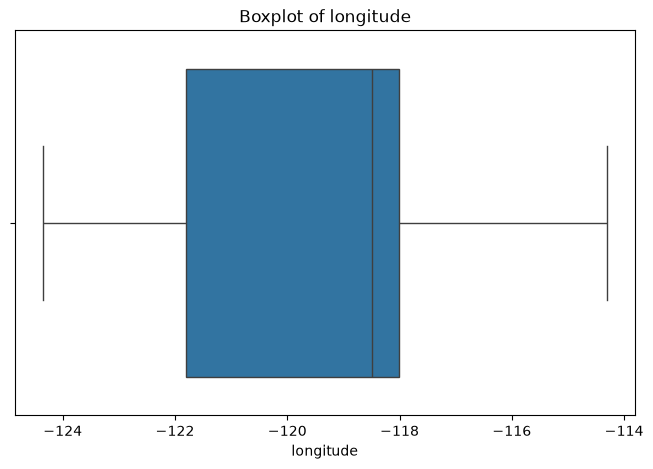

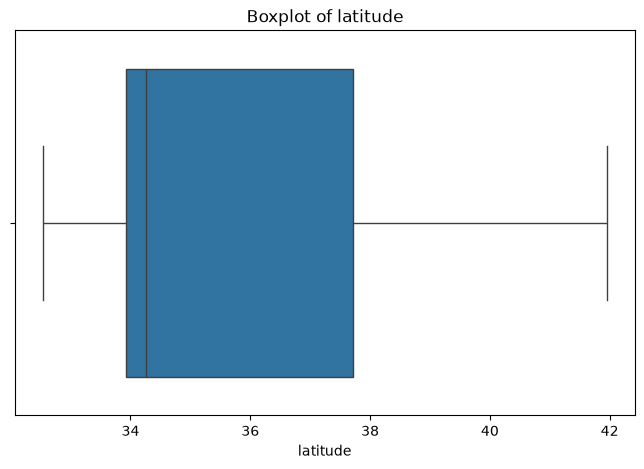

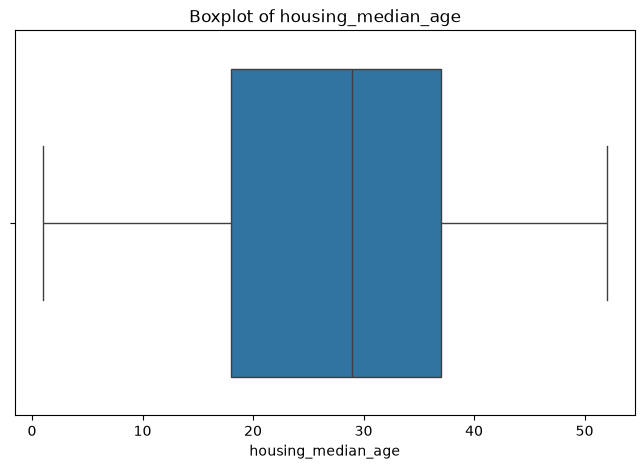

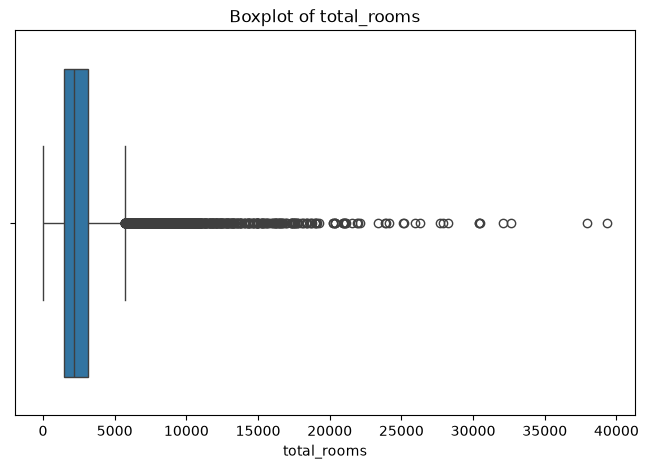

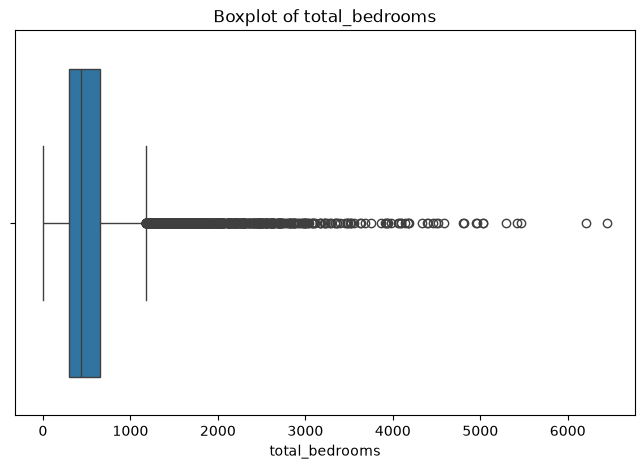

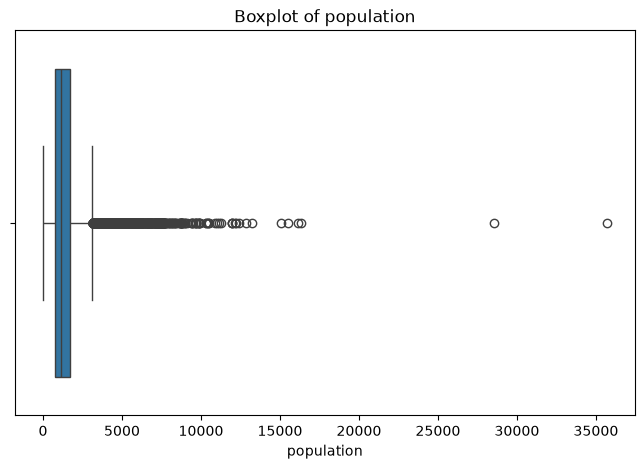

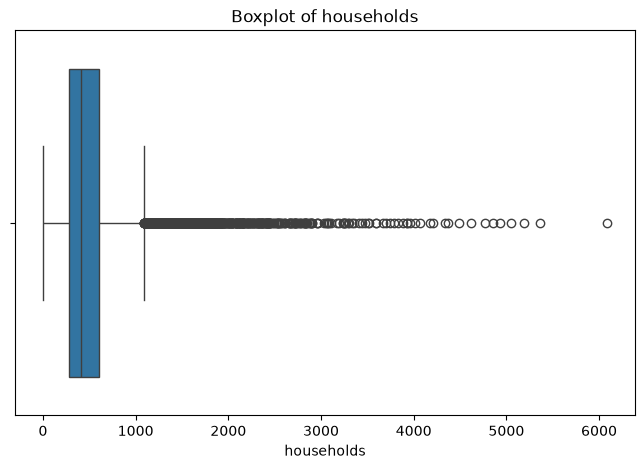

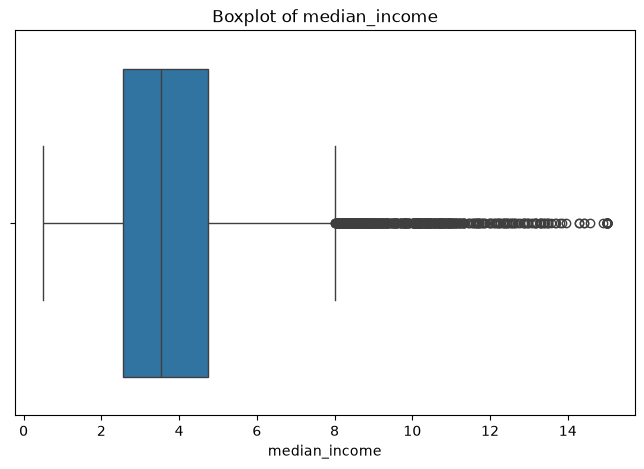

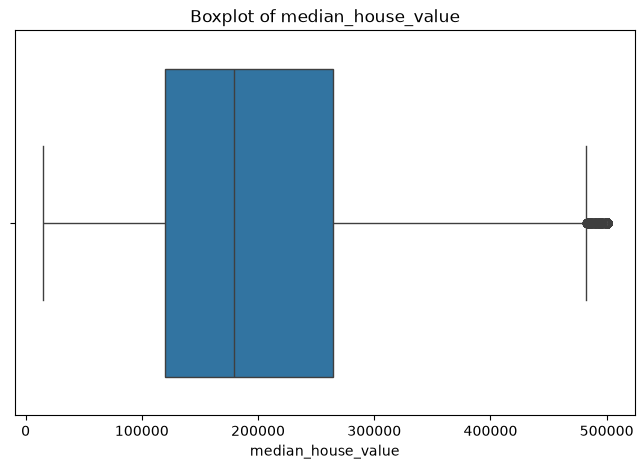

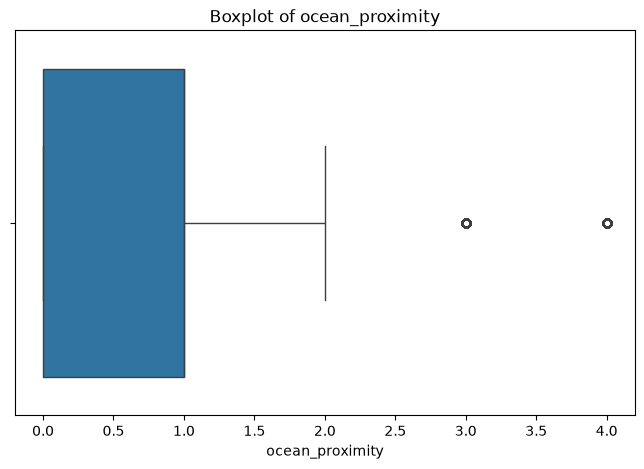

In [8]:
import seaborn as sns

numerical_columns = df.select_dtypes(include="number").columns

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

### Handling Outliers

Boxplots showed potential outliers in most numerical features, except for `longitude`, `latitude`, and `housing_median_age`.

To handle the outliers, we use the **Interquartile Range (IQR) method**. Values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are considered outliers.

The outliers will be removed from the affected numerical columns, while `longitude`, `latitude`, and `housing_median_age` will remain unchanged.


In [10]:
# Columns that contain potential outliers
outlier_columns = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]

# Remove outliers using the IQR method
for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

print(df.shape)

(16725, 10)


In [13]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [14]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [25]:
from sklearn.model_selection import train_test_split
# --- Three-way split: 60% train / 20% val / 20% test ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler
# --- Scaling: fit on train only ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(
    model, X_train_scaled, y_train, cv=5, scoring="r2"
)
print("Cross-Validation R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("Test R²:", r2)

Cross-Validation R² Scores: [0.61269664 0.59819215 0.60423209 0.62130508 0.63047499]
Mean CV R²: 0.6133801885541532
MAE: 42176.95074634196
RMSE: 56309.095844394
Test R²: 0.6260938161228251


### Cross-Validation

We used **5-Fold Cross-Validation** to evaluate the regression model more reliably.

* Split the data into **80% training** and **20% testing**.
* Applied **StandardScaler** to the features.
* Used **5-Fold Cross-Validation** on the training data.
* Calculated the **mean R² score** across the 5 folds.
* Evaluated the final model on the unseen test set.

#### Why?

A single train/test split may give an unreliable evaluation depending on the selected samples. Cross-Validation evaluates the model on multiple subsets, providing a more stable estimate of its performance.

#### Problem Solved

It reduced the risk of relying on a **single validation split** and gave us a more reliable measure of model performance.


In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# --- Proving intentional overfitting: A decision tree with no depth limit ---
overfit_model = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit_model.fit(X_train_scaled, y_train)

train_preds = overfit_model.predict(X_train_scaled)
val_preds = overfit_model.predict(X_val_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

print("\n--- Overfitting Check (Deep Decision Tree) ---")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Gap (Val - Train): {val_rmse - train_rmse:.2f}")


--- Overfitting Check (Deep Decision Tree) ---
Train RMSE: 0.00
Validation RMSE: 62153.07
Gap (Val - Train): 62153.07


#### Overfitting (max_depth=None)

An unrestricted decision tree was trained to test what happens when a model 
is allowed unlimited complexity. The result confirmed overfitting in its 
purest form:

| Metric | Score |
|---|---|
| Train RMSE | 0.00 |
| Validation RMSE | 62,153.07 |
| Gap | 62,153.07 |

A Train RMSE of exactly 0.00 means the tree memorized every training point 
rather than learning a generalizable pattern — and the massive gap to 
Validation RMSE is the direct evidence of that failure to generalize.

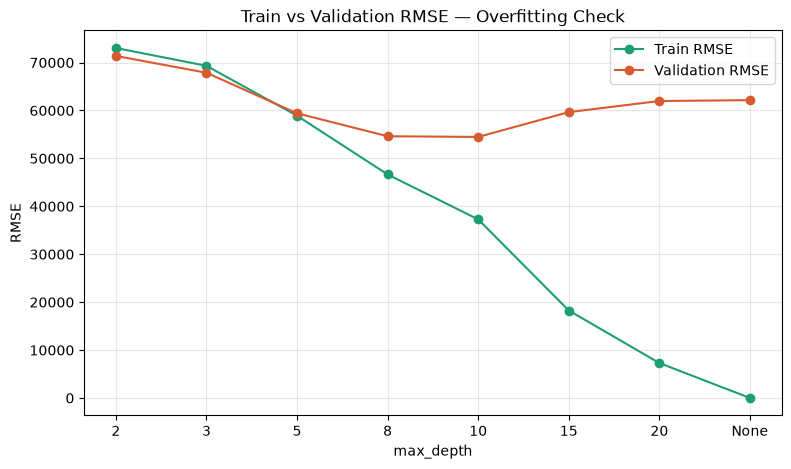

In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

depths = [2, 3, 5, 8, 10, 15, 20, None]
train_errors = []
val_errors = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_pred = model.predict(X_train_scaled)
    val_pred = model.predict(X_val_scaled)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

depth_labels = [str(d) if d is not None else "None" for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(9, 5))
plt.plot(x_pos, train_errors, marker='o', label='Train RMSE', color='#1D9E75')
plt.plot(x_pos, val_errors, marker='o', label='Validation RMSE', color='#D85A30')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Train vs Validation RMSE — Overfitting Check')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Overfitting Check: Train vs Validation RMSE

At `max_depth=2`, both lines are close and high (~70K-73K) — underfitting.

As depth grows, **Train RMSE** drops to near-zero — the tree memorizes 
training data rather than learning general patterns.

**Validation RMSE** improves alongside it until `max_depth≈8-10`, then 
flattens and starts rising slightly (54K → 62K) — the model begins fitting 
noise instead of signal.

The growing gap at `max_depth=None` (Train ≈ 0 vs. Validation ≈ 62K) is the 
classic overfitting signature.

**Takeaway:** best trade-off is around `max_depth=8-10`, where Validation 
RMSE is lowest.

In [31]:
# A deliberately very simple model — only 1 depth (just one decision!)
underfit_model = DecisionTreeRegressor(max_depth=1, random_state=42)
underfit_model.fit(X_train_scaled, y_train)

train_preds = underfit_model.predict(X_train_scaled)
val_preds = underfit_model.predict(X_val_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Gap: {val_rmse - train_rmse:.2f}")

Train RMSE: 79057.22
Validation RMSE: 77118.37
Gap: -1938.85


#### Underfitting (max_depth=1)

At the opposite extreme, a tree limited to a single split was tested to 
confirm the other failure mode:

| Metric | Score |
|---|---|
| Train RMSE | 79,057.22 |
| Validation RMSE | 77,118.37 |
| Gap | 1,938.85 |

Here the gap is small, but both scores are high — the model is too simple 
to capture the data's structure, failing on training data and validation 
data equally. This confirms underfitting: the problem isn't memorization, 
it's insufficient capacity.

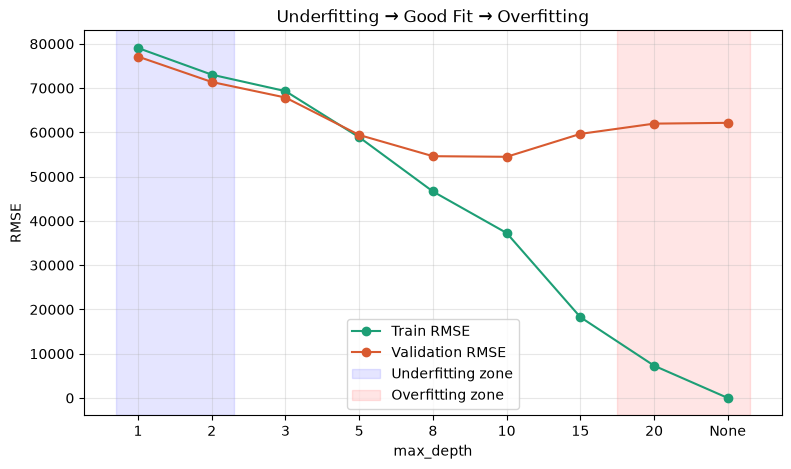

In [33]:
depths = [1, 2, 3, 5, 8, 10, 15, 20, None]
train_errors, val_errors = [], []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_errors.append(np.sqrt(mean_squared_error(y_train, model.predict(X_train_scaled))))
    val_errors.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val_scaled))))

depth_labels = [str(d) if d is not None else "None" for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(9, 5))
plt.plot(x_pos, train_errors, marker='o', label='Train RMSE', color='#1D9E75')
plt.plot(x_pos, val_errors, marker='o', label='Validation RMSE', color='#D85A30')
plt.axvspan(-0.3, 1.3, alpha=0.1, color='blue', label='Underfitting zone')
plt.axvspan(6.5, 8.3, alpha=0.1, color='red', label='Overfitting zone')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Underfitting → Good Fit → Overfitting')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Bias-Variance Tradeoff: Underfitting → Good Fit → Overfitting

This single curve captures the full picture across all three regimes:

- **Underfitting zone (depth 1-2):** both lines are high and close together 
  (~77K-79K) — the model is too simple to learn the pattern at all.
- **Good fit zone (depth ~5-10):** both errors drop and stay close, with 
  Validation RMSE reaching its lowest point (~54K) around depth 8-10.
- **Overfitting zone (depth 15-None):** Train RMSE keeps falling toward 
  zero while Validation RMSE plateaus and creeps back up (~62K) — a 
  widening gap as the model starts memorizing noise.

In [34]:
def evaluate_model(model, name):
    model.fit(X_train_scaled, y_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train_scaled)))
    val_rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val_scaled)))
    gap = val_rmse - train_rmse
    print(f"{name}: Train RMSE={train_rmse:.2f}, Val RMSE={val_rmse:.2f}, Gap={gap:.2f}")
    return train_rmse, val_rmse, gap

# Original model: overfitting obvious
overfit = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit_scores = evaluate_model(overfit, "Overfit (max_depth=None)")

# Regularized model: limit depth + set minimum samples per leaf
regularized = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=20,   # each leaf must contain at least 20 samples
    random_state=42
)
regularized_scores = evaluate_model(regularized, "Regularized (max_depth=10, min_samples_leaf=20)")

Overfit (max_depth=None): Train RMSE=0.00, Val RMSE=62153.07, Gap=62153.07
Regularized (max_depth=10, min_samples_leaf=20): Train RMSE=45580.26, Val RMSE=50954.80, Gap=5374.54


#### Fix: Regularization (max_depth=10, min_samples_leaf=20)

To address the overfitting case, two constraints were added: a depth cap 
and a minimum sample count per leaf, forcing the tree to learn patterns 
general enough to apply to groups of similar houses rather than individual 
data points.

| Metric | Overfit | Regularized | Change |
|---|---|---|---|
| Train RMSE | 0.00 | 45,580.26 | ↑ (expected trade-off) |
| Validation RMSE | 62,153.07 | 50,954.80 | ↓ 18% |
| Gap | 62,153.07 | 5,374.54 | ↓ 91% |

The regularized model gave up perfect training performance but gained a 
substantially better, more honest Validation RMSE — proof that reducing 
complexity, not increasing it, was the right fix here.

| Regime | Train RMSE | Val RMSE | Gap | Diagnosis |
|---|---|---|---|---|
| Underfit (depth=1) | 79,057.22 | 77,118.37 | 1,938.85 | Too simple |
| Overfit (depth=None) | 0.00 | 62,153.07 | 62,153.07 | Memorized training data |
| Regularized (depth=10) | 45,580.26 | 50,954.80 | 5,374.54 | Best generalization |

Across all three models, the lowest Validation RMSE — the metric that 
actually matters for unseen data — belongs to the regularized model, 
confirming that a well-constrained tree outperforms both an overly simple 
and an overly complex one.